In [1]:
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager", repos="http://cran.r-project.org")
}

#BiocManager::install("yardstick", lib='/nfs/home/vgrether/.conda/envs/Rv4.4.1/lib/R/library')

suppressPackageStartupMessages(library(VariantAnnotation))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(vroom))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(randomcoloR))
suppressPackageStartupMessages(library(ggsignif))

library(RColorBrewer)

### DLBCL Samples

In [109]:
dir <- "/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/DLBCL/pileup_summaries" 
files <- list.files(path = dir, pattern = "*_pileup_noHeader.txt", full.names = TRUE)

all_samples <- data.frame(
    SAMPLE=character(),
    contig=character(),
    position=numeric(),
    ref_count=numeric(),
    alt_count=numeric(),
    other_alt_count=numeric(),
    allele_frequency=numeric(),
    Label=character()
)

In [110]:
for (file in files) {
    sample <- sub("_pileup_noHeader.txt", "", basename(file))
    variant_labels <- file.path(dir, paste0(sample, ".labels.txt"))
    if (!file.exists(variant_labels)) {
        next
    }
    label_counts <- vroom(variant_labels, show_col_types = FALSE) %>%
        mutate(POS = as.numeric(POS))
    pileups <- vroom(file, show_col_types = FALSE) %>%
        filter((ref_count + alt_count + other_alt_count) > 0) 
    
    data <- pileups %>%
        inner_join(label_counts, by=c("contig"="Chrom","position"="POS")) %>%
        mutate(SAMPLE=sample) %>%
        #filter((ref_count + alt_count) > 5) %>%
        group_by(SAMPLE) %>%
        select(c(SAMPLE, contig, position, ref_count, alt_count, other_alt_count, allele_frequency, Label))
    all_samples <- rbind(all_samples, data)
}

In [16]:
options(repr.plot.width = 12, repr.plot.height = 7)

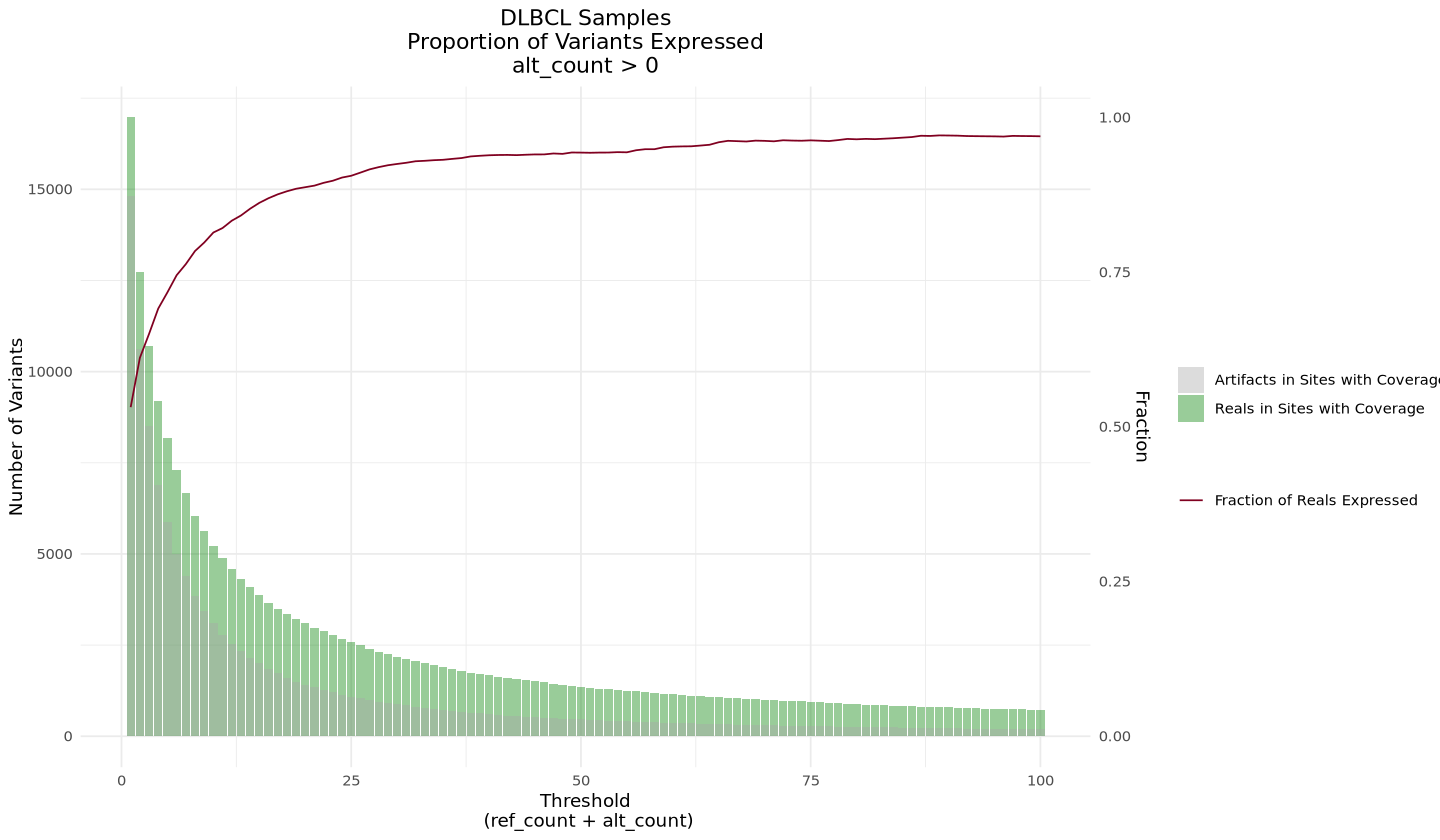

In [161]:
equation = function(x){all_samples %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(
                number_reals = sum(Label == "Real") ,
                number_artifacts = sum(Label == "Artifact"),
                proportion_reals_expressed = sum(Label == "Real" & alt_count>0) / sum(Label == "Real")
            ) }

thresholds <- seq(1, 100, by = 1)
proportions <- do.call(rbind, lapply(thresholds, equation))

coeff=max(proportions$number_reals)
data.frame(thresholds, proportions) %>%
  ggplot(aes(x=thresholds)) +
  geom_bar(aes(y=number_reals, fill = "Reals in Sites with Coverage"),stat="identity",alpha=0.4) + 
  geom_bar(aes(y=number_artifacts, fill = "Artifacts in Sites with Coverage"),stat="identity",alpha=0.4) + 
  geom_line(aes(y=proportion_reals_expressed*coeff, color = "Fraction of Reals Expressed")) +
  labs(title = "DLBCL Samples\nProportion of Variants Expressed\nalt_count > 0",
       x = "Threshold\n (ref_count + alt_count)",
       y= "Proportion",
      color = "",
      fill="")+
  theme_minimal()+
  scale_color_manual(values = c("Fraction of Reals Expressed" = "#800020"))+
  scale_fill_manual(values=c("Artifacts in Sites with Coverage" = "#A9A9A9" ,
                               "Reals in Sites with Coverage" = "#008000")) +
  theme(plot.title = element_text(hjust = 0.5),
       legend.position = "right") +
  scale_y_continuous(
    name = "Number of Variants",
    sec.axis = sec_axis(~ . /coeff, name="Fraction")) 

#### Proportion of Real Variants Expressed

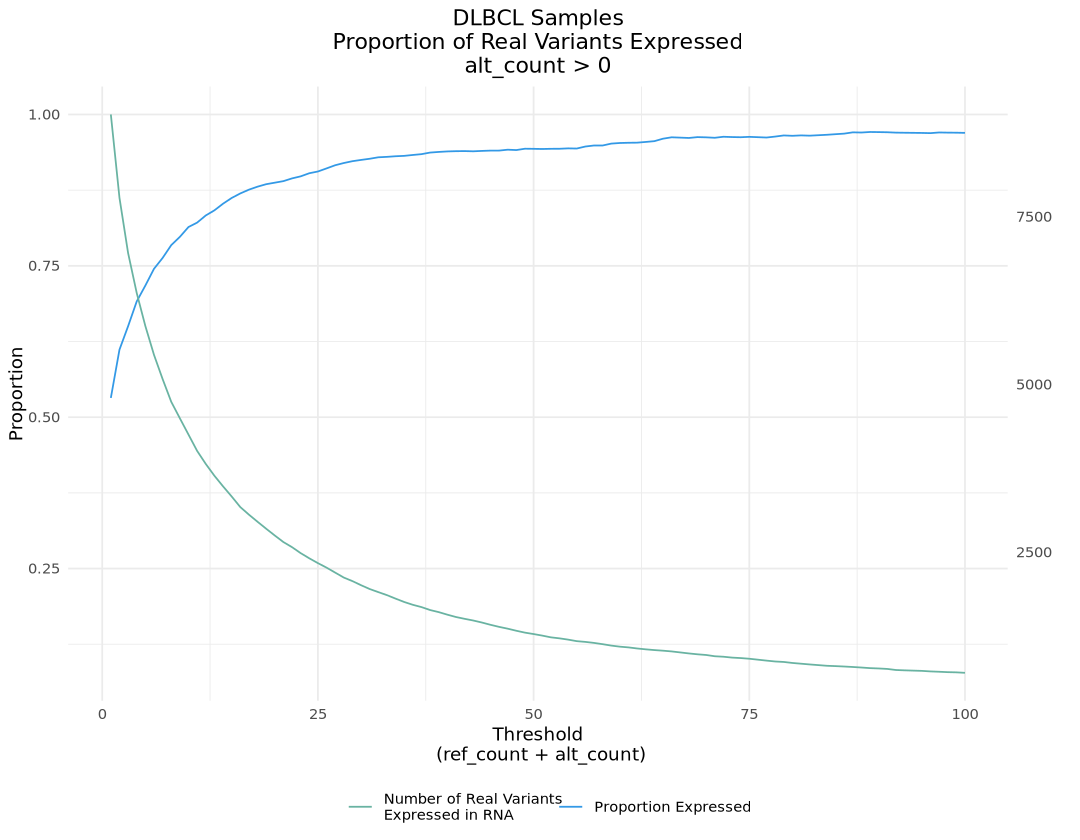

In [129]:
eq_reals = function(x){all_samples %>%
            ungroup() %>%
            filter(Label == "Real") %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(propotion_reals = sum(alt_count > 0) / n()) %>%
            pull(propotion_reals)}

eq_num_reals = function(x){
            all_samples %>%
            ungroup() %>%
            filter(Label == "Real") %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(num_reals = sum(alt_count > 0)) %>%
            pull(num_reals)}

thresholds <- seq(1, 100, by = 1)
proportion_reals <- sapply(thresholds, eq_reals)
num_reals <- sapply(thresholds, eq_num_reals)

#data.frame(thresholds, proportion_reals, num_reals) %>%
#    ggplot(aes(x = thresholds, y = proportion_reals)) +
#    geom_line() +
#    geom_point() +
#    labs(title = "Proportion of Real Variants Expressed\nalt_count > 0",
#       x = "Threshold\n (ref_count + alt_count)",
#       y = "Proportion") +
#    theme_minimal() + 
#    ylim(0,1)

coeff=max(num_reals)
data.frame(thresholds, proportion_reals, num_reals) %>%
ggplot(aes(x=thresholds)) +
  geom_line(aes(y=proportion_reals, color = "Proportion Expressed")) + 
  geom_line(aes(y=num_reals / coeff, color = "Number of Real Variants\nExpressed in RNA")) +
  labs(title = "DLBCL Samples\nProportion of Real Variants Expressed\nalt_count > 0",
       x = "Threshold\n (ref_count + alt_count)",
      color = "")+
  theme_minimal()+
  scale_color_manual(values = c("Proportion Expressed" = rgb(0.2, 0.6, 0.9, 1), 
   "Number of Real Variants\nExpressed in RNA" = "#69b3a2")) +
  theme(plot.title = element_text(hjust = 0.5),
       legend.position = "bottom") +
  scale_y_continuous(
    name = "Proportion",
    sec.axis = sec_axis(~ . *coeff, name="")) 

## P1000 Samples

In [ ]:
## Recreating Plots 

In [5]:
ffpolish_data <- vroom("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ffpolish/original_model/SAMBAI/all_samples_ffpolish_truthset.txt",
                      show_col_types=FALSE) %>%
                mutate(FFPolish = ifelse(Probability_Real > 0.5, 1, 0))

Rows: 1681016 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Sample, Variant
dbl (2): Probability_Artifact, Probability_Real

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
ebm_percentages <- vroom("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/SAMBAI/HighConfidence/predictions/sambai.rot_dlbcl.csv",
                        show_col_types=FALSE) %>%
    mutate(chrom_pos = str_replace(Variant, "_.*", "")) %>%
    rename(EBM_ROT_DLBCL_probability = 'Prediction')

ebm_percentages <- vroom("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/SAMBAI/HighConfidence/predictions/sambai.all4.csv",
                        show_col_types=FALSE) %>%
    rename(EBM_all4_probability = 'Prediction') %>%
    inner_join(ebm_percentages, by=c("Sample", "Variant"))

ebm_percentages <- vroom("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/SAMBAI/HighConfidence/predictions/sambai.rot_dlbcl_blgsp.csv",
                        show_col_types=FALSE) %>%
    #select(-c("Cohort")) %>%
    #mutate(chrom_pos = str_replace(Variant, "_.*", "")) %>%
    rename(EBM_BLGSP = 'Prediction') %>%
    inner_join(ebm_percentages, by=c("Sample", "Variant")) #"tumor_VAF"

ebm_percentages <- vroom("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/SAMBAI/HighConfidence/predictions/sambai.rot_dlbcl_htmcp.csv",
                        show_col_types=FALSE) %>%
    rename(EBM_HTMCP = 'Prediction') %>%
    inner_join(ebm_percentages, by=c("Sample", "Variant")) 

Rows: 3520256 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Sample, Variant
dbl (2): tumor_VAF_scaled, Prediction

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3520256 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Sample, Variant
dbl (2): tumor_VAF_scaled, Prediction

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3520256 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Sample, Variant
dbl (2): tumor_VAF_scaled, Prediction

ℹ Use `spec()` to re

In [7]:
data <- ebm_percentages %>%
    filter(Sample %in% ffpolish_data$Sample) %>%
    left_join(ffpolish_data, by=c("Sample"="Sample", "Variant"="Variant")) %>%
    mutate(FFPolish = replace_na(FFPolish, 0)) %>%
    distinct(Sample, Variant, .keep_all = TRUE)

In [8]:
dir <- "/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/SAMBAI/HighConfidence/pileup_summaries" 
files <- list.files(path = dir, pattern = "*_pileup_noHeader.txt", full.names = TRUE)

sample_pileups <- data.frame(
    Sample=character(),
    chrom_pos=character(),
    ref_count=numeric(),
    alt_count=numeric(),
    other_alt_count=numeric(),
    allele_frequency=numeric()
)

for (file in files) {
    sample <- sub("_pileup_noHeader.txt", "", basename(file))
    
    pileups <- vroom(file, show_col_types = FALSE) %>%
        filter((ref_count + alt_count + other_alt_count) > 0) %>%
        mutate(Sample = str_replace(sample, "--.*", "")) %>%
        mutate(chrom_pos = paste0(contig, ":", position)) %>%
        select(c("Sample", "chrom_pos", everything())) %>%
        select(-c("contig", "position"))
    
    sample_pileups <- rbind(sample_pileups, pileups)
}

In [9]:
data <- data %>%
    inner_join(sample_pileups, by=c("Sample","chrom_pos")) %>%
    distinct(Sample, Variant, .keep_all = TRUE) %>%
    rename(tumor_VAF = allele_frequency) %>%
    select(-c(chrom_pos, Probability_Artifact, Probability_Real)) 

ERROR: Error: object 'sample_pileups' not found


In [ ]:
eq_reals = function(x){data %>%
            ungroup() %>%
            filter((ref_count + alt_count + other_alt_count) > x) %>%
            summarize(
                number_Reals = sum((alt_count > 0))
            ) %>% 
            pull(number_Reals)}

eq_artifacts = function(x){data %>%
            ungroup() %>%
            filter((ref_count + alt_count + other_alt_count) > x) %>%
            summarize(
                number_Artifacts = sum(alt_count == 0)
            ) %>% 
            pull(number_Artifacts)}

coverage <- seq(1,100, by=1)
number_reals <- sapply(coverage, eq_reals)
number_artifacts <- sapply(coverage, eq_artifacts)

In [ ]:
final_df <- data.frame(
    coverage = coverage,
    number_Reals = number_reals,
    number_Artifacts = number_artifacts
)

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 3.7)

annotation_data <- final_df %>% 
    filter(coverage == 5 | coverage == 50 | coverage == 20) %>%  #coverage == 1
    select(coverage, number_Reals, number_Artifacts)

final_df %>%
    ggplot(aes(x = coverage)) +
    geom_line(aes(y=number_Reals, color="Real"), linetype="solid",  linewidth=1.2)+
    geom_line(aes(y=number_Artifacts, color="Artifact"), linetype="solid",  linewidth=1.2)+
    geom_point(data = annotation_data, aes(x=coverage, y=number_Reals, color="Real"), show.legend = FALSE, size=3) + 
    geom_point(data = annotation_data, aes(x=coverage, y=number_Artifacts, color="Artifact"), show.legend = FALSE, size=3) +
    scale_x_continuous(
        breaks = seq(0, 100, by = 10)
    ) +
    scale_color_manual(
    values = c("Artifact" = "brown", "Real" = "steelblue")
    ) +
    labs(
    x = "Minimum Coverage Threshold",
    y = "Variant Counts",
    title = "Number of Variants \nAcross Coverage Thresholds",
    color = "Variant\nClassification"
    ) +
    geom_text(data = annotation_data, aes(x = coverage, y=number_Reals, label=number_Reals, color="Real"), show.legend = FALSE, vjust=-0.3, hjust=-0.2, size=4) +
    geom_text(data = annotation_data, aes(x = coverage, y=number_Artifacts, label=number_Artifacts, color="Artifact"),show.legend = FALSE, vjust=-1.5, hjust=0.1, size=4) +
    theme_minimal() +
    theme(
    plot.title = element_text(hjust = 0.5, size=14),
    axis.title.x= element_text(size=12),
    axis.text.x = element_text(size=9),
    axis.text.y = element_text(size=9),
    axis.title.y= element_text(size=12, hjust=0.5),
    legend.title = element_text(size=12),
    legend.text = element_text(size=11)
    ) + 
    ylim(c(0, 15000)) 

ggsave(
  filename = "variants_plot.pdf", 
  width = 8, height = 3.7,            
  units = "in"                      
)

In [ ]:
coverage <- seq(1,100, by=1)

## Precision

precision <- data.frame(
    Sample=character(),
    coverage_threshold = numeric(),
    FFPolish = numeric(),
    EBM_all4 = numeric(),
    EBM_ROT_DLBCL = numeric(),
    EBM_HTMCP = numeric(),
    EBM_BLGSP = numeric(),
    VAF = numeric()
)

for (cov in coverage) {
    result <- data %>%
    ungroup() %>%
    filter((ref_count + alt_count + other_alt_count) > cov) %>%
    summarize(
        coverage_threshold = cov,
        FFPolish = sum((FFPolish == 1) & (alt_count > 0)) / sum(FFPolish == 1),
        EBM_all4 = sum((EBM_all4_probability > 0.5) & (alt_count > 0)) / sum(EBM_all4_probability > 0.5),
        EBM_ROT_DLBCL = sum((EBM_ROT_DLBCL_probability > 0.5) & (alt_count > 0)) / sum(EBM_ROT_DLBCL_probability > 0.5),
        EBM_HTMCP = sum((EBM_HTMCP > 0.5) & (alt_count > 0)) / sum(EBM_HTMCP > 0.5),
        EBM_BLGSP = sum((EBM_BLGSP > 0.5) & (alt_count > 0)) / sum(EBM_BLGSP > 0.5),
        VAF = sum((tumor_VAF > 0.1) & (alt_count > 0)) / sum(tumor_VAF > 0.1)
    )
    precision <- bind_rows(precision, result)
}

## Sensitivity

sensitivity <- data.frame(
    Sample=character(),
    coverage_threshold = numeric(),
    FFPolish = numeric(),
    EBM_all4 = numeric(),
    EBM_ROT_DLBCL = numeric(),
    EBM_HTMCP = numeric(),
    EBM_BLGSP = numeric(),
    VAF = numeric()
)

for (cov in coverage) {
    result <- data %>%
    ungroup() %>%
    filter((ref_count + alt_count + other_alt_count) > cov) %>%
    summarize(
        coverage_threshold = cov,
        FFPolish = sum((FFPolish == 1) & (alt_count > 0)) / sum(alt_count > 0),
        EBM_all4 = sum((EBM_all4_probability >= 0.5) & (alt_count > 0)) / sum(alt_count > 0),
        EBM_ROT_DLBCL = sum((EBM_ROT_DLBCL_probability >= 0.5) & (alt_count > 0)) / sum(alt_count > 0),
        EBM_HTMCP = sum((EBM_HTMCP >= 0.5) & (alt_count > 0)) / sum(alt_count > 0),
        EBM_BLGSP = sum((EBM_BLGSP >= 0.5) & (alt_count > 0)) / sum(alt_count > 0),
        VAF = sum((tumor_VAF >= 0.1) & (alt_count > 0)) / sum(alt_count > 0)
    )
    sensitivity <- bind_rows(sensitivity, result)
}

## Specificity

specificity <- data.frame(
    Sample=character(),
    coverage_threshold = numeric(),
    FFPolish = numeric(),
    EBM_all4 = numeric(),
    EBM_ROT_DLBCL = numeric(),
    VAF = numeric()
)

for (cov in coverage) {
    result <- data %>%
    ungroup() %>%
    filter((ref_count + alt_count + other_alt_count) > cov) %>%
    summarize(
        coverage_threshold = cov,
        FFPolish = sum((FFPolish == 0) & (alt_count == 0)) / sum(alt_count == 0),
        EBM_all4 = sum((EBM_all4_probability <= 0.5) & (alt_count == 0)) / sum(alt_count == 0),
        EBM_ROT_DLBCL = sum((EBM_ROT_DLBCL_probability <= 0.5) & (alt_count == 0)) / sum(alt_count == 0),
        VAF = sum((tumor_VAF <= 0.1) & (alt_count == 0)) / sum(alt_count == 0)
    )
    specificity <- bind_rows(specificity, result)
}

#F1 Score

f1_score <- data.frame(
    Sample=character(),
    coverage_threshold = numeric(),
    FFPolish = numeric(),
    EBM_all4 = numeric(),
    EBM_ROT_DLBCL = numeric(),
    EBM_HTMCP = numeric(),
    EBM_BLGSP = numeric(),
    VAF = numeric()
)

for (cov in coverage) {
    result <- data %>%
    ungroup() %>%
    filter((ref_count + alt_count + other_alt_count) > cov) %>%
    summarize(
        coverage_threshold = cov,
        FFPolish = sum((FFPolish == 1) & (alt_count > 0)) / (sum((FFPolish == 1) & (alt_count > 0)) + 0.5 * (sum((FFPolish == 1) & (alt_count == 0)) + sum((FFPolish == 0) & (alt_count > 0)))),
        EBM_all4 = sum((EBM_all4_probability >= 0.5) & (alt_count > 0)) / (sum((EBM_all4_probability > 0.5) & (alt_count > 0)) + 0.5 * (sum((EBM_all4_probability > 0.5) & (alt_count == 0)) + sum((EBM_all4_probability <= 0.5) & (alt_count > 0)))),
        EBM_ROT_DLBCL = sum((EBM_ROT_DLBCL_probability >= 0.5) & (alt_count > 0)) / (sum((EBM_ROT_DLBCL_probability > 0.5) & (alt_count > 0)) + 0.5 * (sum((EBM_ROT_DLBCL_probability > 0.5) & (alt_count == 0)) + sum((EBM_ROT_DLBCL_probability <= 0.5) & (alt_count > 0)))),
        EBM_HTMCP = sum((EBM_HTMCP >= 0.5) & (alt_count > 0)) / (sum((EBM_HTMCP > 0.5) & (alt_count > 0)) + 0.5 * (sum((EBM_HTMCP > 0.5) & (alt_count == 0)) + sum((EBM_HTMCP <= 0.5) & (alt_count > 0)))),
        EBM_BLGSP = sum((EBM_BLGSP >= 0.5) & (alt_count > 0)) / (sum((EBM_BLGSP > 0.5) & (alt_count > 0)) + 0.5 * (sum((EBM_BLGSP > 0.5) & (alt_count == 0)) + sum((EBM_BLGSP <= 0.5) & (alt_count > 0)))),
        VAF = sum((tumor_VAF > 0.1) & (alt_count > 0)) / (sum((tumor_VAF > 0.1) & (alt_count > 0)) + 0.5 * (sum((tumor_VAF > 0.1) & (alt_count == 0)) + sum((tumor_VAF <= 0.1) & (alt_count > 0))))
    )
    f1_score <- bind_rows(f1_score, result)
}

In [ ]:
options(repr.plot.width = 7, repr.plot.height = 7)
f1_score %>%
    ggplot(aes(x = factor(coverage_threshold))) +
  geom_line(aes(y = FFPolish, group = 1, color = "FFPolish"), linetype = "solid", linewidth = 1.2) +
  geom_line(aes(y = EBM_all4, group = 1, color = "EBM - 4 cohorts"), linetype = "dotted", linewidth = 1.2) +
  geom_line(aes(y = EBM_ROT_DLBCL, group = 1, color = "EBM - DLBCL + ROT"), linetype = "twodash", linewidth = 1.2) +
  geom_line(aes(y = EBM_HTMCP, group = 1, color = "EBM - DLBCL + ROT + HTMCP"), linetype = "dashed", linewidth = 1.2) +
  geom_line(aes(y = EBM_BLGSP, group = 1, color = "EBM - DLBCL + ROT + BLGSP"), linetype = "solid", linewidth = 1.2) +
  geom_line(aes(y = VAF, group = 1, color = "VAF_10"), linetype = "solid", linewidth = 1.2) +
  scale_x_discrete(
    breaks = seq(0, 100, by = 10)
  ) +
    scale_color_manual(
    labels = c("FFPolish" = "FFPolish", 
               "EBM - 4 cohorts" = "FIFA [all cohorts]", 
               "EBM - DLBCL + ROT" = "FIFA [NYGC1 + NYGC2]", 
               "EBM - DLBCL + ROT + HTMCP" = "FIFA [NYGC1 + NYGC2 + HTMCP]", 
               "EBM - DLBCL + ROT + BLGSP" = "FIFA [NYGC1 + NYGC2 + BLGSP]", 
               "VAF_10" = "VAF 10%"),
    values = c(
          "FFPolish" = "#80B1D3",              
          "EBM - 4 cohorts" = "#EEBFBF",       
          "EBM - DLBCL + ROT" = "#DE7F7F",     
          "EBM - DLBCL + ROT + HTMCP" = "#CD3F3F", 
          "EBM - DLBCL + ROT + BLGSP" = "#BD0000",
          "VAF_10" = "#8DD3C7"                 
        )
    ) +
    labs(
    x = "Coverage Threshold\n(ref_count + alt_count)",
    y = "F1 Score",
    title = "F1 Score\nFIFA, FFPolish, and 10% VAF Cut-Off", #\nin NYGC3 Cohort",
        color = "Filtering Method"
    ) +
    scale_y_continuous(limits=c(0.5, 1.0)) + 
    theme_minimal() +
    theme(
    plot.title = element_text(hjust = 0.5),
    axis.title.y = element_text(size=12),
    axis.title.x = element_text(size=12),
    legend.text = element_text(size = 11),
    legend.title = element_text(size = 13)
    )
ggsave("/nfs/home/vgrether/curve.pdf", width=7, height=7)

#### EBM Labels

In [2]:
dir <- "/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/SAMBAI/HighConfidence/pileup_summaries" 
files <- list.files(path = dir, pattern = "*_pileup_noHeader.txt", full.names = TRUE)

all_samples <- data.frame(
    SAMPLE=character(),
    ref_count=numeric(),
    alt_count=numeric(),
    other_alt_count=numeric(),
    allele_frequency=numeric(),
    Label=character()
)

for (file in files) {
    sample <- sub("_pileup_noHeader.txt", "", basename(file))
    variant_labels <- file.path(dir, paste0(sample, "_ebm_labels.txt"))
    
    if (!file.exists(variant_labels)) {
        next
    }
    
    label_counts <- vroom(variant_labels, show_col_types = FALSE) %>%
        mutate(POS = as.numeric(POS)) %>%
        rename(LABEL = EBM)
    
    pileups <- vroom(file, show_col_types = FALSE) %>%
        filter((ref_count + alt_count + other_alt_count) > 0) 
    
    data <- pileups %>%
        inner_join(label_counts, by=c("contig"="CHROM","position"="POS")) %>%
        group_by(SAMPLE) %>%
        select(c(SAMPLE, contig, position, ref_count, alt_count, other_alt_count, allele_frequency, LABEL))
    all_samples <- rbind(all_samples, data)
}

In [ ]:
ebm_predictions <- vroom("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/SAMBAI/HighConfidence/predictions")

In [ ]:
ffpolish_data <- vroom("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ffpolish/original_model/SAMBAI/all_samples_ffpolish_truthset.txt",
                      show_col_types=FALSE)

all_samples <- all_samples %>%
    rename("EBM" = "LABEL") %>%
    left_join(ffpolish_data, by=c("SAMPLE"="SAMPLE", "contig"="CHROM", "position"="POS")) %>%
    replace(is.na(.), 0)

In [3]:
eq_sensitivity = function(x){all_samples %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(sensitivity = sum(EBM & alt_count > 0) / sum(alt_count > 0)) %>%
            pull(sensitivity)}

eq_specificity = function(x){all_samples %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(specificity = sum(!EBM & alt_count == 0) / sum(alt_count == 0)) %>%
            pull(specificity)}

thresholds <- seq(1,100, by=1)
sensitivity_EBM <- sapply(thresholds, eq_sensitivity)
specificity_EBM <- sapply(thresholds, eq_specificity)

data.frame(thresholds, sensitivity_EBM, specificity_EBM) %>%
    ggplot(aes(x=thresholds)) +
    geom_line(aes(y=sensitivity_EBM, color="Sensitivity"), size=1.2)+
    geom_line(aes(y=specificity_EBM, color="Specificity"), size=1.2)+
    theme_minimal() + 
    labs(title = "Sensitivity and Specificity\nEBM Calls in P1000 Cohort",
         x = "Thresholds\n(ref_count + alt_count)",
         y = "",
        color = "Metric") +
    scale_y_continuous(lim=c(0,1))+
    scale_color_manual(values = c("Sensitivity" = "steelblue", "Specificity" = "grey")) +
    theme(
        plot.title = element_text(hjust = 0.5, size = 14),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        legend.position = "right",
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 10)
    )


ERROR: [1m[33mError[39m in `summarize()`:[22m
[1m[22m[36mℹ[39m In argument: `sensitivity = sum(EBM & alt_count > 0)/sum(alt_count > 0)`.
[1mCaused by error:[22m
[33m![39m object 'EBM' not found


#### 10% VAF Cutoff

In [6]:
VAF_data <- all_samples %>%
    mutate(VAF_LABEL = ifelse(allele_frequency > 0.1, 1, 0))

In [7]:
# This can for SURE be condensed but for now it works 

eq_sensitivity = function(x){VAF_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(sensitivity = sum(VAF_LABEL & alt_count > 0) / sum(alt_count > 0)) %>%
            pull(sensitivity)}

eq_specificity = function(x, label){VAF_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(specificity = sum(!VAF_LABEL & alt_count == 0) / sum(alt_count == 0)) %>%
            pull(specificity)}

thresholds <- seq(1,100, by=1)
sensitivity_VAF <- sapply(thresholds, eq_sensitivity)
specificity_VAF <- sapply(thresholds, eq_specificity)

eq_sensitivity = function(x){VAF_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(sensitivity = sum(FFPOLISH & alt_count > 0) / sum(alt_count > 0)) %>%
            pull(sensitivity)}

eq_specificity = function(x, label){VAF_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(specificity = sum(!FFPOLISH & alt_count == 0) / sum(alt_count == 0)) %>%
            pull(specificity)}

sensitivity_FFPOLISH <- sapply(thresholds, eq_sensitivity)
specificity_FFPOLISH <- sapply(thresholds,  eq_specificity)

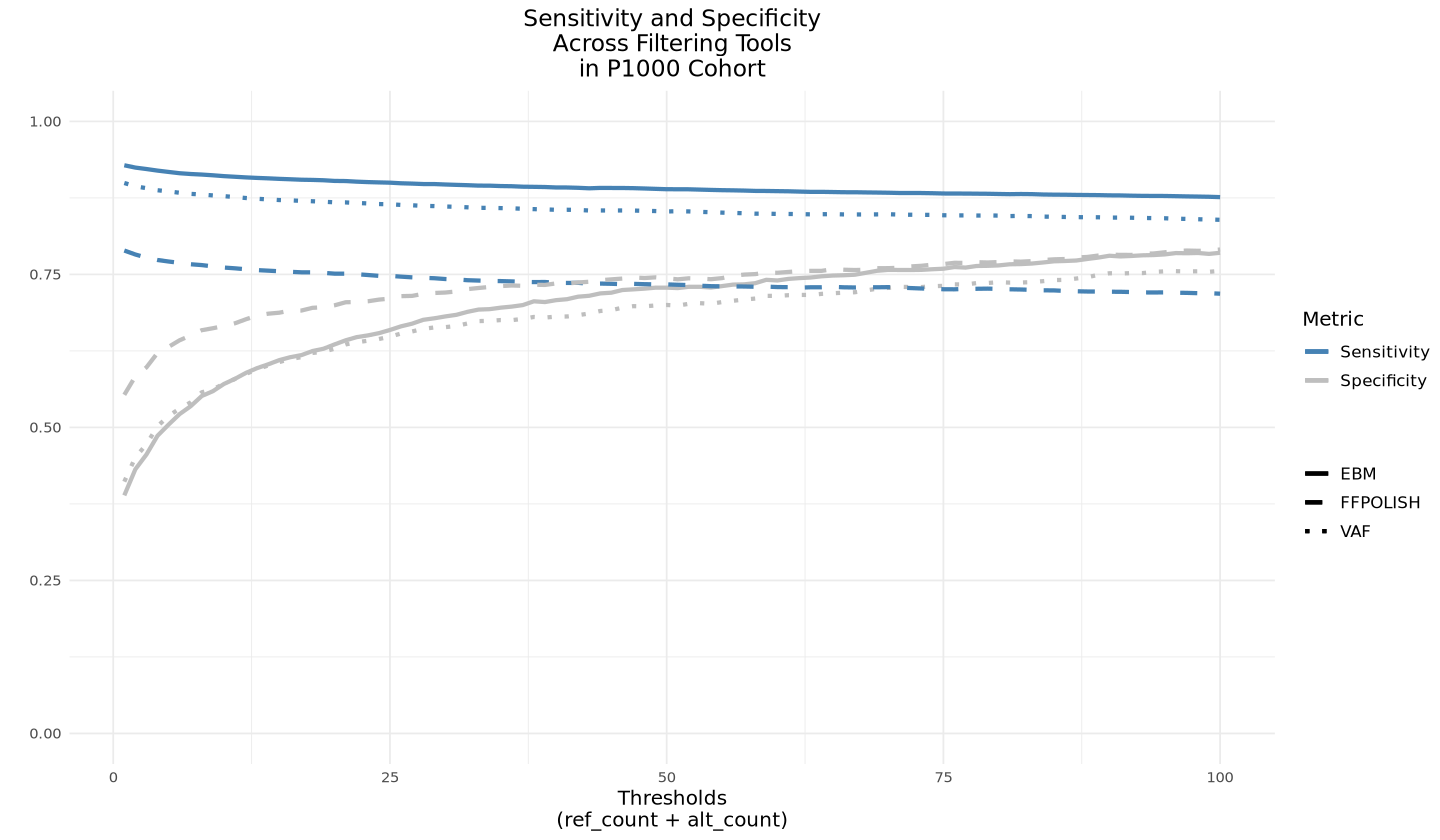

In [245]:
data.frame(thresholds, sensitivity_UF, sensitivity_VAF, specificity_VAF, 
           sensitivity_EBM, specificity_EBM, sensitivity_FFPOLISH, specificity_FFPOLISH, 
           sensitivity_IDEAFIX, specificity_IDEAFIX) %>%
    ggplot(aes(x=thresholds)) +
    geom_line(aes(y=sensitivity_VAF, color="Sensitivity", linetype="VAF"),  size=1.2)+
    geom_line(aes(y=specificity_VAF, color="Specificity", linetype="VAF"),  size=1.2)+
    geom_line(aes(y=sensitivity_EBM, color="Sensitivity", linetype="EBM"), size=1.2)+
    geom_line(aes(y=specificity_EBM, color="Specificity", linetype="EBM"), size=1.2)+
    geom_line(aes(y=sensitivity_FFPOLISH, color="Sensitivity", linetype="FFPOLISH"), size=1.2)+
    geom_line(aes(y=specificity_FFPOLISH, color="Specificity", linetype="FFPOLISH"), size=1.2)+
    geom_line(aes(y=sensitivity_IDEAFIX, color="Sensitivity", linetype="FFPOLISH"), size=1.2)+
    geom_line(aes(y=specificity_IDEAFIX, color="Specificity", linetype="FFPOLISH"), size=1.2)+
    theme_minimal() + 
    labs(title = "Sensitivity and Specificity\nAcross Filtering Tools\nin P1000 Cohort",
         x = "Thresholds\n(ref_count + alt_count)",
         y = "",
        color = "Metric",
        linetype="") +
    scale_y_continuous(lim=c(0,1))+
    scale_color_manual(values = c("Sensitivity" = "steelblue", "Specificity" = "grey",
                                 "Unfiltered" = "black")) +
    scale_linetype_manual(values = c("VAF" = "dotted", "EBM" = "solid",
                                    "FFPOLISH" = "dashed"))  + 
    theme(
        plot.title = element_text(hjust = 0.5, size = 14),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        legend.position = "right",
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 10)
    )

In [94]:
files <- list.files(path = "/gpfs/commons/groups/compbio/projects/FFPE_filtering/wliao/sambai", pattern = "*predictions.txt", full.names = TRUE)

ideafix <- data.frame(
    SAMPLE=character(),
    CHROM=character(),
    POS=numeric(),
    IDEAFIX_LABEL=character()
)

In [95]:
for (file in files) {
    data <- vroom(file, show_col_types=FALSE) %>%
        mutate(
            SAMPLE = paste0(tumor,"--", normal),
            IDEAFIX_LABEL = ifelse(DEAMINATION == "non-deamination", 1, 0)
        ) %>%
        select(c("SAMPLE", "CHROM", "POS", "IDEAFIX_LABEL"))
    
    ideafix <- rbind(ideafix, data)
}

In [96]:
ideafix <- ideafix %>%
    mutate(SAMPLE  = str_replace(SAMPLE, '\\.snv\\.indel\\.final\\.v6\\.annotated$', ""))

In [97]:
ideafix_data <- VAF_data %>%
    left_join(ideafix, by=c("SAMPLE"="SAMPLE", "contig"="CHROM", "position"="POS")) %>%
    filter(!is.na(IDEAFIX_LABEL))

In [106]:
eq_sensitivity = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(sensitivity = sum(EBM & alt_count > 0) / sum(alt_count > 0)) %>%
            pull(sensitivity)}

eq_specificity = function(x, label){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(specificity = sum(!EBM & alt_count == 0) / sum(alt_count == 0)) %>%
            pull(specificity)}

sensitivity_EBM <- sapply(thresholds, eq_sensitivity)
specificity_EBM <- sapply(thresholds,  eq_specificity)

eq_sensitivity = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(sensitivity = sum(VAF_LABEL & alt_count > 0) / sum(alt_count > 0)) %>%
            pull(sensitivity)}

eq_specificity = function(x, label){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(specificity = sum(!VAF_LABEL & alt_count == 0) / sum(alt_count == 0)) %>%
            pull(specificity)}

sensitivity_VAF <- sapply(thresholds, eq_sensitivity)
specificity_VAF <- sapply(thresholds,  eq_specificity)

eq_sensitivity = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(sensitivity = sum(FFPOLISH & alt_count > 0) / sum(alt_count > 0)) %>%
            pull(sensitivity)}

eq_specificity = function(x, label){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(specificity = sum(!FFPOLISH & alt_count == 0) / sum(alt_count == 0)) %>%
            pull(specificity)}

sensitivity_FFPOLISH <- sapply(thresholds, eq_sensitivity)
specificity_FFPOLISH <- sapply(thresholds,  eq_specificity)

eq_sensitivity = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(sensitivity = sum(IDEAFIX_LABEL & alt_count > 0) / sum(alt_count > 0)) %>%
            pull(sensitivity)}

eq_specificity = function(x, label){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(specificity = sum(!IDEAFIX_LABEL & alt_count == 0) / sum(alt_count == 0)) %>%
            pull(specificity)}

sensitivity_IDEAFIX <- sapply(thresholds, eq_sensitivity)
specificity_IDEAFIX <- sapply(thresholds,  eq_specificity)

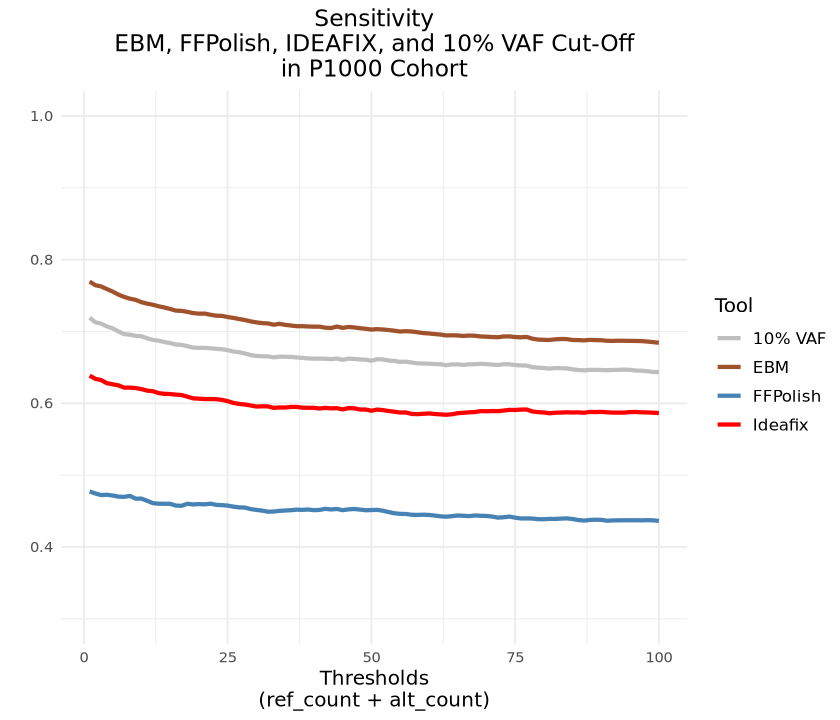

In [113]:
options(repr.plot.width = 7, repr.plot.height = 6)

data.frame(thresholds, sensitivity_VAF,
           sensitivity_EBM, sensitivity_FFPOLISH, sensitivity_IDEAFIX) %>%
    ggplot(aes(x=thresholds)) +
    geom_line(aes(y=sensitivity_VAF, color="10% VAF"), linetype="solid",  size=1.2)+
    geom_line(aes(y=sensitivity_EBM, color="EBM"), linetype="solid", size=1.2)+
    geom_line(aes(y=sensitivity_FFPOLISH, color="FFPolish"),linetype="solid", size=1.2)+
    geom_line(aes(y=sensitivity_IDEAFIX, color="Ideafix"),linetype="solid", size=1.2)+
    theme_minimal() + 
    labs(title = "Sensitivity\nEBM, FFPolish, IDEAFIX, and 10% VAF Cut-Off\nin P1000 Cohort",
         x = "Thresholds\n(ref_count + alt_count)",
         y = "",
        color = "Tool",
        linetype="") +
    scale_y_continuous(lim=c(0.3,1))+
    scale_color_manual(values = c("EBM" = "#A0522D", "FFPolish" = "steelblue",
                                  "10% VAF" = "grey", 
                                 "Unfiltered" = "black",
                                 "Ideafix" = "red")) +
    theme(
        plot.title = element_text(hjust = 0.5, size = 14),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        legend.position = "right",
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 10)
    )

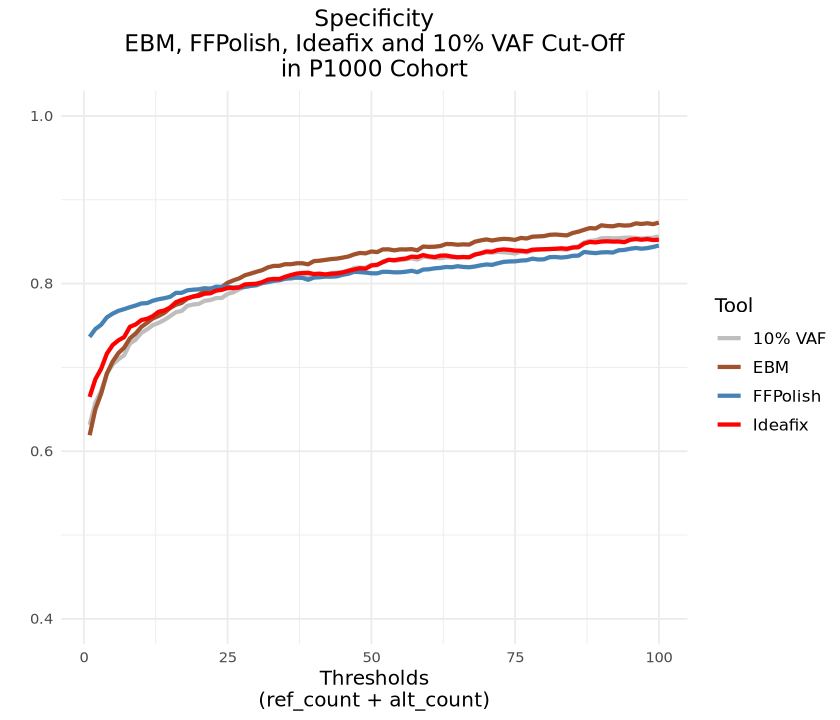

In [117]:
data.frame(thresholds, specificity_VAF,
           specificity_EBM, specificity_FFPOLISH,
          specificity_IDEAFIX) %>%
    ggplot(aes(x=thresholds)) +
    geom_line(aes(y=specificity_VAF, color="10% VAF"), linetype="solid",  size=1.2)+
    geom_line(aes(y=specificity_EBM, color="EBM"), linetype="solid", size=1.2)+
    geom_line(aes(y=specificity_FFPOLISH, color="FFPolish"),linetype="solid", size=1.2)+
    geom_line(aes(y=specificity_IDEAFIX, color="Ideafix"),linetype="solid", size=1.2)+
    theme_minimal() + 
    labs(title = "Specificity\nEBM, FFPolish, Ideafix and 10% VAF Cut-Off\nin P1000 Cohort",
         x = "Thresholds\n(ref_count + alt_count)",
         y = "",
        color = "Tool",
        linetype="") +
    scale_y_continuous(lim=c(0.4, 1))+
    scale_color_manual(values = c("EBM" = "#A0522D", "FFPolish" = "steelblue",
                                  "10% VAF" = "grey" ,
                                 "Ideafix" = "red")) + #, "Unfiltered" = "black")) +
    theme(
        plot.title = element_text(hjust = 0.5, size = 14),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        legend.position = "right",
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 10)
    ) 

In [114]:
## For overall predictions please switch data frame ideafix_data for VAF_data

eq_precision = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(precision = sum(alt_count > 0) / n()) %>%
            pull(precision)}

precision_UF <- sapply(thresholds, eq_precision)

eq_precision = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(precision = sum(EBM & alt_count > 0) / sum(EBM)) %>%
            pull(precision)}

precision_EBM <- sapply(thresholds, eq_precision)

eq_precision = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(precision = sum(VAF_LABEL & alt_count > 0) / sum(VAF_LABEL)) %>%
            pull(precision)}

precision_VAF <- sapply(thresholds, eq_precision)

eq_precision = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(precision = sum(FFPOLISH & alt_count > 0) / sum(FFPOLISH)) %>%
            pull(precision)}

precision_FFPOLISH <- sapply(thresholds, eq_precision)

eq_precision = function(x){ideafix_data %>%
            ungroup() %>%
            filter((ref_count + alt_count) > x) %>%
            summarize(precision = sum(IDEAFIX_LABEL & alt_count > 0) / sum(IDEAFIX_LABEL)) %>%
            pull(precision)}

precision_IDEAFIX <- sapply(thresholds, eq_precision)

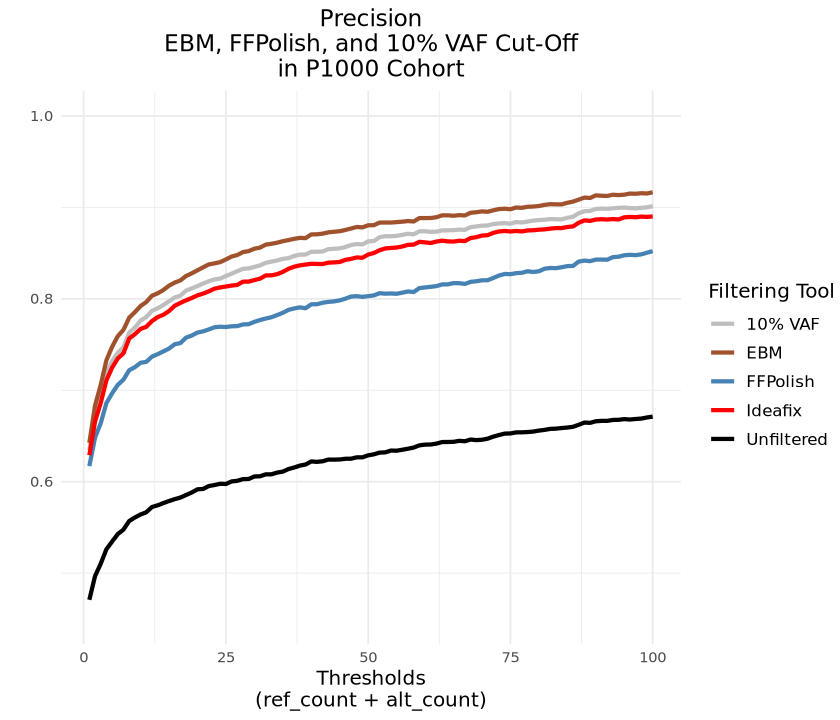

In [116]:
data.frame(thresholds, precision_UF, precision_FFPOLISH,
           precision_EBM, precision_VAF, precision_IDEAFIX) %>%
    ggplot(aes(x=thresholds)) +
    geom_line(aes(y=precision_UF, color="Unfiltered"), linetype="solid",  size=1.2)+
    geom_line(aes(y=precision_VAF, color="10% VAF"), linetype="solid",  size=1.2)+
    geom_line(aes(y=precision_EBM, color="EBM"), linetype="solid", size=1.2)+
    geom_line(aes(y=precision_FFPOLISH, color="FFPolish"),linetype="solid", size=1.2)+
    geom_line(aes(y=precision_IDEAFIX, color="Ideafix"),linetype="solid", size=1.2)+
    theme_minimal() + 
    labs(title = "Precision\nEBM, FFPolish, and 10% VAF Cut-Off\nin P1000 Cohort",
         x = "Thresholds\n(ref_count + alt_count)",
         y = "",
        color = "Filtering Tool",
        linetype="") +
    scale_y_continuous(lim=c(0.45,1))+
    scale_color_manual(values = c("EBM" = "#A0522D", "FFPolish" = "steelblue",
                                  "10% VAF" = "grey", 
                                 "Unfiltered" = "black",
                                 "Ideafix" = "red")) +
    theme(
        plot.title = element_text(hjust = 0.5, size = 14),
        axis.title.x = element_text(size = 12),
        axis.title.y = element_text(size = 12),
        legend.position = "right",
        legend.title = element_text(size = 12),
        legend.text = element_text(size = 10)
    )

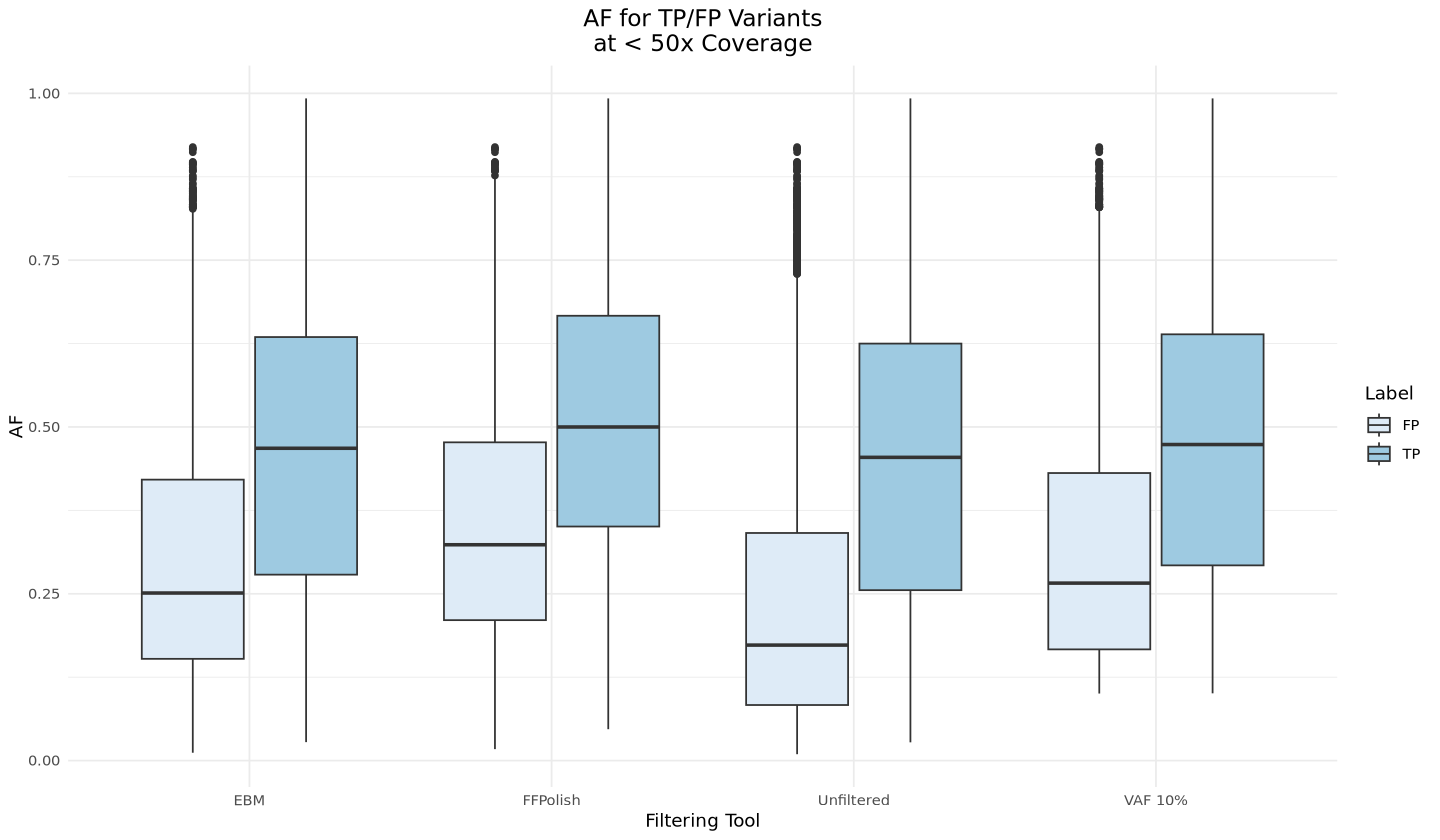

In [262]:
vaf_data <- VAF_data %>%
    ungroup() %>%
    filter(alt_count + ref_count < 50) %>%
    filter(VAF_LABEL == 1) %>%
    mutate(tool= "VAF 10%",
          Label=ifelse(alt_count > 0, "TP", "FP")) %>%
     select(c(SAMPLE, tool, Label, allele_frequency))

ebm_data <- VAF_data %>%
    ungroup() %>%
    filter(alt_count + ref_count < 50) %>%
    filter(EBM == 1) %>%
    mutate(tool= "EBM",
          Label=ifelse(alt_count > 0, "TP", "FP")) %>%
     select(c(SAMPLE, tool, Label, allele_frequency))


ffpolish_data <- VAF_data %>%
    ungroup() %>%
    filter(alt_count + ref_count < 50) %>%
    filter(FFPOLISH == 1) %>%
    mutate(tool= "FFPolish",
          Label=ifelse(alt_count > 0, "TP", "FP")) %>%
     select(c(SAMPLE, tool, Label, allele_frequency))


unfiltered_data <- VAF_data %>%
    ungroup() %>%
    filter(alt_count + ref_count < 50) %>%
    mutate(tool= "Unfiltered",
          Label=ifelse(alt_count > 0, "TP", "FP")) %>%
     select(c(SAMPLE, tool, Label, allele_frequency))

rbind(vaf_data, ebm_data, ffpolish_data, unfiltered_data) %>%
    ggplot(aes(x=tool, y=allele_frequency, fill=Label)) + 
    geom_boxplot() + 
    labs(
        title="AF for TP/FP Variants\nat < 50x Coverage",
        x="Filtering Tool",
        y= "AF",
        legend=""
    ) + 
    theme_minimal() + 
    theme(
        plot.title=element_text(hjust=0.5, size=14),
        legend.position="right"
    ) + 
    scale_fill_brewer(palette="Blues")

In [123]:
names(ideafix_data)

[1] "SAMPLE"           "contig"           "position"         "ref_count"       
 [5] "alt_count"        "other_alt_count"  "allele_frequency" "EBM"             
 [9] "FFPOLISH"         "VAF_LABEL"        "IDEAFIX_LABEL"

In [121]:
ideafix_data %>%
    filter(
        EBM & 
        !FFPOLISH &
        !VAF_LABEL &
        !IDEAFIX_LABEL &
        alt_count > 0 &
        ref_count + alt_count > 50
    ) %>% write.csv("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/SAMBAI/HighConfidence/pileup_summaries/variants_EBM_performance.csv")

## Preliminary Testing on BLGSP Samples

In [124]:
data <- vroom("/gpfs/commons/groups/compbio/projects/FFPE_filtering/vgrether/ebm/blgsp/vcfs/counts.csv")

Rows: 10 Columns: 5
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Sample
dbl (4): HC_TN, HC_FP, HC_TP, HC_FN

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


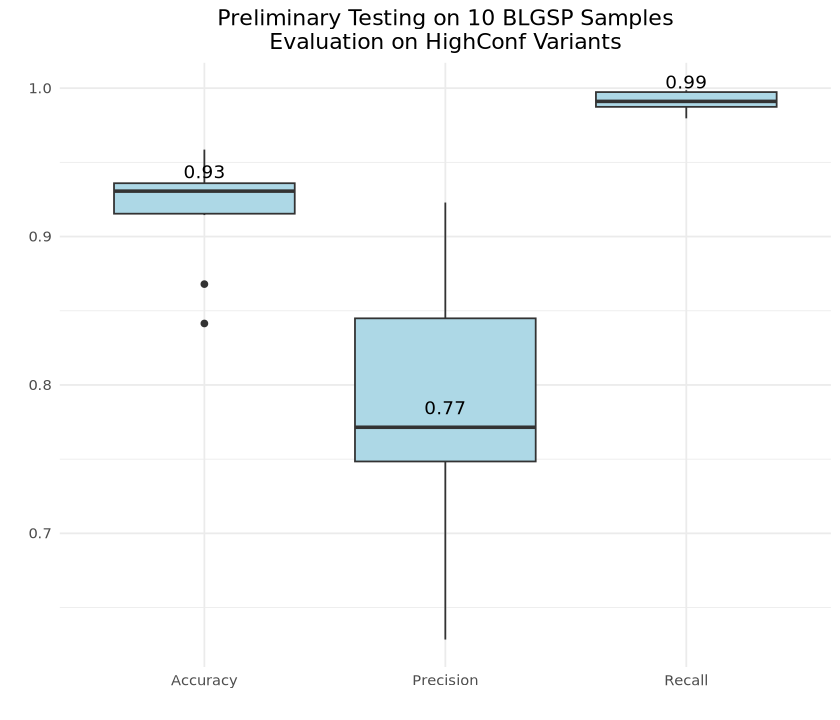

In [139]:
data %>%
    group_by(Sample) %>%
    summarize(
        Recall = HC_TP / (HC_TP + HC_FN),
        #Specificity = HC_TN / (HC_TN + HC_FP),
        Precision = HC_TP / (HC_TP + HC_FP),
        Accuracy = (HC_TN + HC_TP) / (HC_TN + HC_TP + HC_FP + HC_FN)
    ) %>%
    pivot_longer(
        cols=c(Accuracy, Precision, Recall),
        names_to="Metric",
        values_to="Vals"
    ) %>%
    ggplot(aes(x=Metric, y=Vals)) +
    geom_boxplot(fill='lightblue') +  
    stat_summary(
        fun = median,
        geom = "text",
        aes(label = round(..y.., 2)),
        vjust = -1,
        color = "black"
    ) +
    theme_minimal() + 
    labs(
        title="Preliminary Testing on 10 BLGSP Samples\nEvaluation on HighConf Variants",
        x="",
        y=""
    ) +
    theme(
        plot.title=element_text(hjust=0.5)
    )

### Random pero no se adonde más enchufar esto

In [27]:
scores <- data.frame(
    Tool = c("DeepSomatic", "ClairS", "Strelka2","EBM - FFG_GZ_T_24h-B","EBM - FFG_GZ_T_24h-F", "EBM - FFG_IL_T_24h"),
    Recall = c(0.8241, 0.8148, 0.8259, 0.9931, 0.9943, 0.9920),
    Precision = c(0.9447, 0.7997, 0.7560, 0.9435, 0.9319, 0.9400), 
    F1 = c(0.8803, 0.8072, 0.7894, 0.9677, 0.9621, 0.9653))

In [34]:
scores <- data.frame(
    Tool = c("DeepSomatic", "EBM - FFG_GZ_T_24h-B","EBM - FFG_GZ_T_24h-F", "EBM - FFG_IL_T_24h"),
    Recall = c(0.8241,  0.9931, 0.9943, 0.9920),
    Precision = c(0.9447,  0.9435, 0.9319, 0.9400), 
    F1 = c(0.8803, 0.9677, 0.9621, 0.9653))

In [35]:
options(repr.plot.width = 12, repr.plot.height = 5)

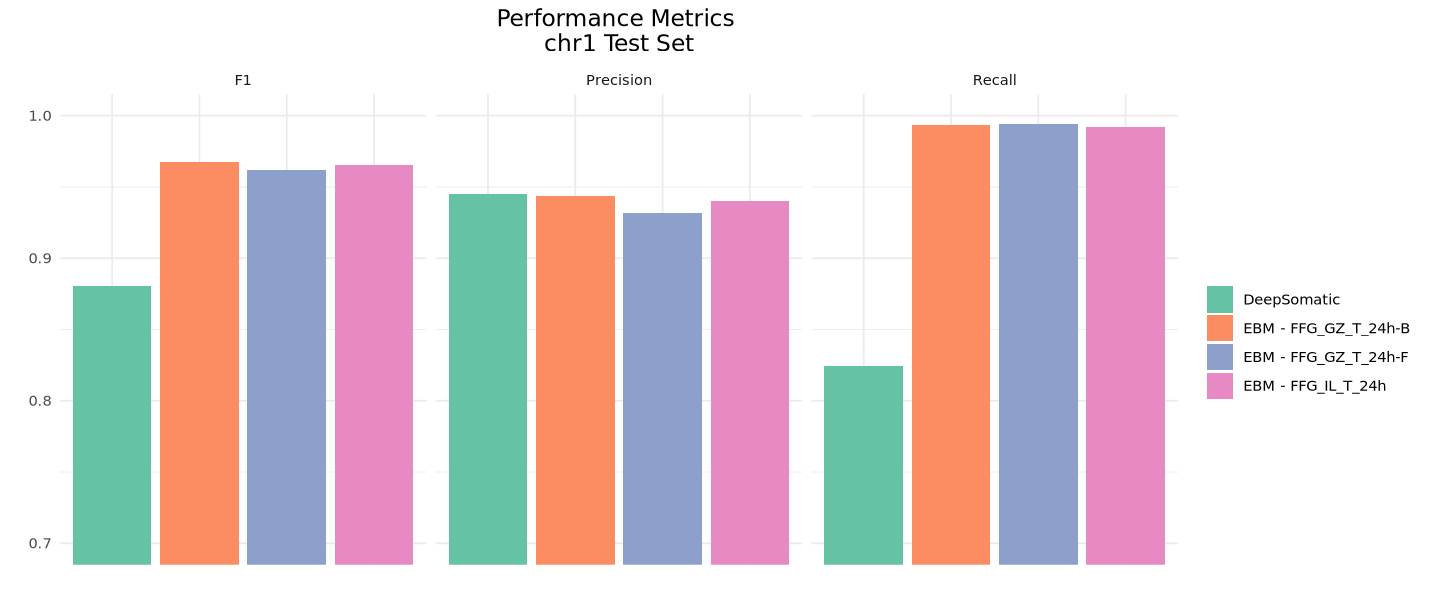

In [39]:
scores %>% 
    pivot_longer(cols=c("Recall", "Precision", "F1"),
                names_to = "Metric",
                values_to = "Vals") %>%
    mutate(Tool = factor(Tool, levels=c("DeepSomatic", "EBM - FFG_GZ_T_24h-B","EBM - FFG_GZ_T_24h-F", "EBM - FFG_IL_T_24h"))) %>%
    ggplot(aes(x=interaction(Tool, Metric), y= Vals, fill = Tool)) +
    geom_bar(stat="identity") + 
    labs(title="Performance Metrics \nchr1 Test Set",
        x = "",
        y = "",
        fill = "") +
    theme_minimal() +
    theme(
        plot.title = element_text(hjust=0.5, size=14),
        axis.text.x = element_blank()
    ) + 
    scale_fill_brewer(palette = "Set2") + 
    facet_wrap(~Metric, ncol=3, scales="free_x") + 
    coord_cartesian(ylim = c(0.7, 1))

#### Original Method

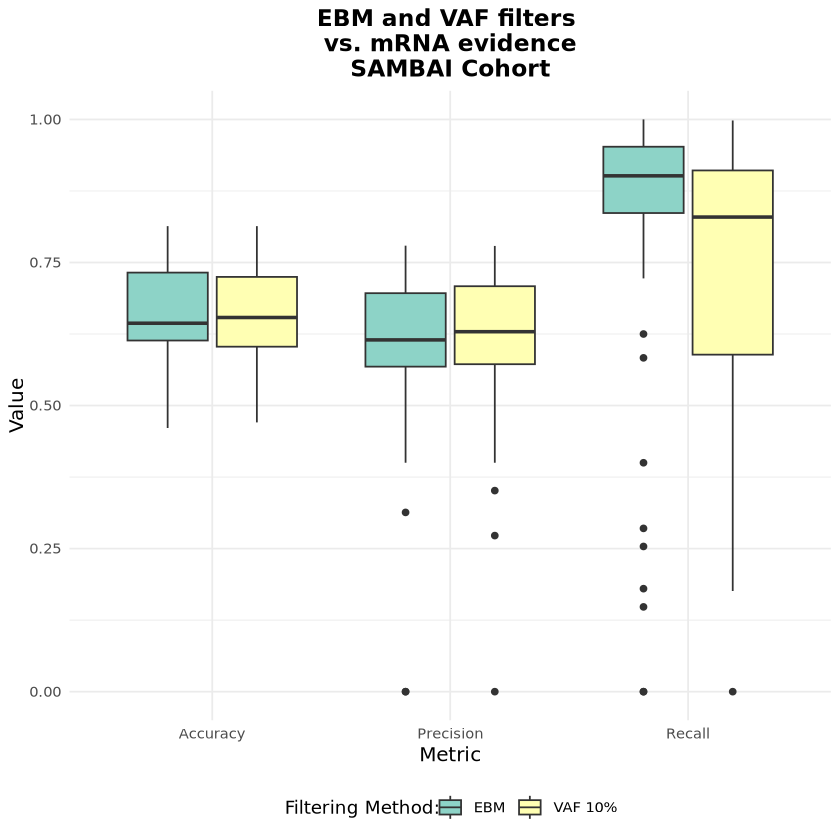

In [4]:
all_samples %>%
    mutate(TOOL = "EBM") %>%
    rbind(VAF_data %>% mutate(TOOL = "VAF 10%")) %>%
    group_by(TOOL, SAMPLE) %>%
    mutate(
        Accuracy = (TP + TN) / (TP + FP + TN + FN),
        Precision = TP / (TP + FP),
        Recall = TP / (TP + FN)
    ) %>%
    select(c(TOOL, SAMPLE, Accuracy, Precision, Recall)) %>%
    pivot_longer(cols=c("Accuracy", "Precision", "Recall"),
                values_to="VALUE",
                names_to="METRIC") %>%
    ggplot(aes(x=METRIC, y=VALUE,fill=TOOL)) + 
    geom_boxplot() + 
    theme_minimal() +
    scale_fill_brewer(palette = "Set3") + 
    labs(
    title = "EBM and VAF filters \nvs. mRNA evidence\nSAMBAI Cohort",
    x = "Metric",
    y = "Value",
    fill = "Filtering Method: "
    ) +
    theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title.x = element_text(size = 12),
    axis.title.y = element_text(size = 12),
    legend.position = "bottom"
    )


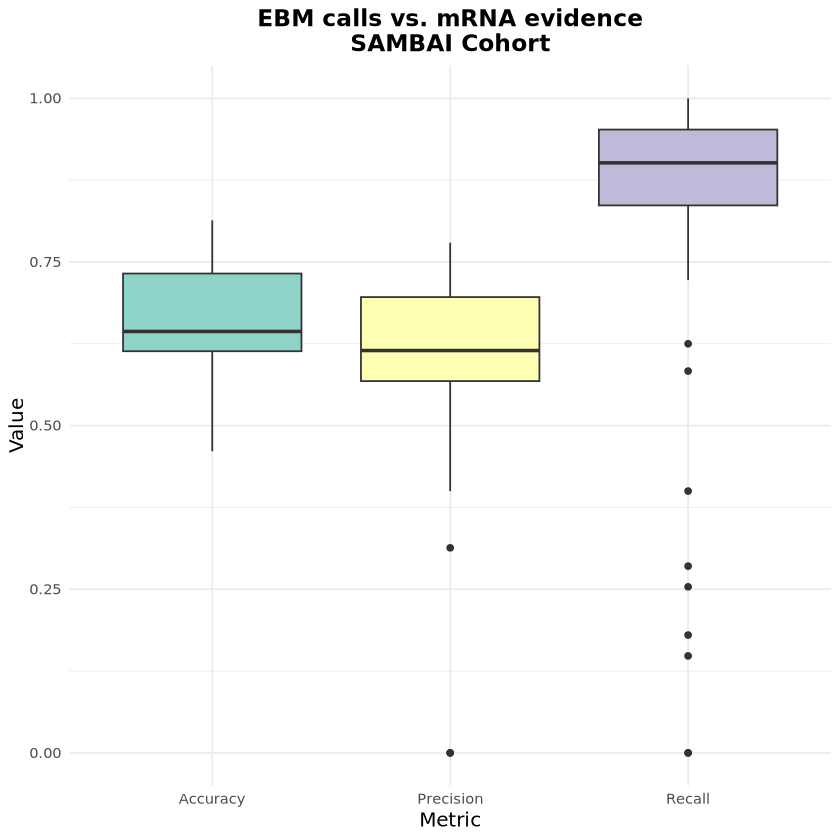

In [5]:
all_samples %>%
    mutate(
        Accuracy = (TP + TN) / (TP + FP + TN + FN),
        Precision = TP / (TP + FP),
        Recall = TP / (TP + FN)
    ) %>%
    select(c(SAMPLE, Accuracy, Precision, Recall)) %>%
    pivot_longer(cols=c("Accuracy", "Precision", "Recall"),
                values_to="VALUE",
                names_to="METRIC") %>%
    ggplot(aes(x=METRIC, y=VALUE,fill=METRIC)) + 
    geom_boxplot() + 
    theme_minimal() +
    scale_fill_brewer(palette = "Set3") + 
    labs(
    title = "EBM calls vs. mRNA evidence\nSAMBAI Cohort",
    x = "Metric",
    y = "Value",
    fill = "Metric"
    ) +
    theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title.x = element_text(size = 12),
    axis.title.y = element_text(size = 12),
    legend.position = "None"
    )

In [6]:
coverage_data <- data.frame(
    SAMPLE = character(),
    ref_count = numeric(),
    alt_count = numeric(),
    other_alt_count = numeric(),
    coverage_at_site = numeric()
)

for (file in files) {
    sample <- sub("_pileup_noHeader.txt", "", basename(file))
    emb_counts_file <- file.path(dir, paste0(sample, "_ebm_labels.txt"))
    ebm_counts <- vroom(emb_counts_file, show_col_types = FALSE) 
    pileups <- vroom(file, show_col_types = FALSE) %>%
        filter((ref_count + alt_count + other_alt_count) > 0)
    
    data <- pileups %>%
        left_join(ebm_counts, by=c("contig"="CHROM","position"="POS")) %>%
        filter(!is.na(EBM)) %>%
        #filter((ref_count + alt_count) > 5) %>%
        group_by(SAMPLE) %>%
        mutate(
            coverage_at_site = ref_count + alt_count + other_alt_count
        ) %>%
        select(c(SAMPLE, ref_count, alt_count, other_alt_count, coverage_at_site))
    
    coverage_data <- rbind(coverage_data, data)
}

In [9]:
print(head(coverage_data$coverage_at_site))
print(tail(coverage_data$coverage_at_site))

[1] 1529    3    8   32    4    3
[1]   8  51   1 168   1   6


In [87]:
test <- coverage_data %>%
    group_by(SAMPLE) %>%
    filter((ref_count + alt_count) > 5) %>%
    summarize(
        Total=n()
    )

sum(test$Total)

[1] 20617

Warning message:
“Removed 1116 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_bar()`).”


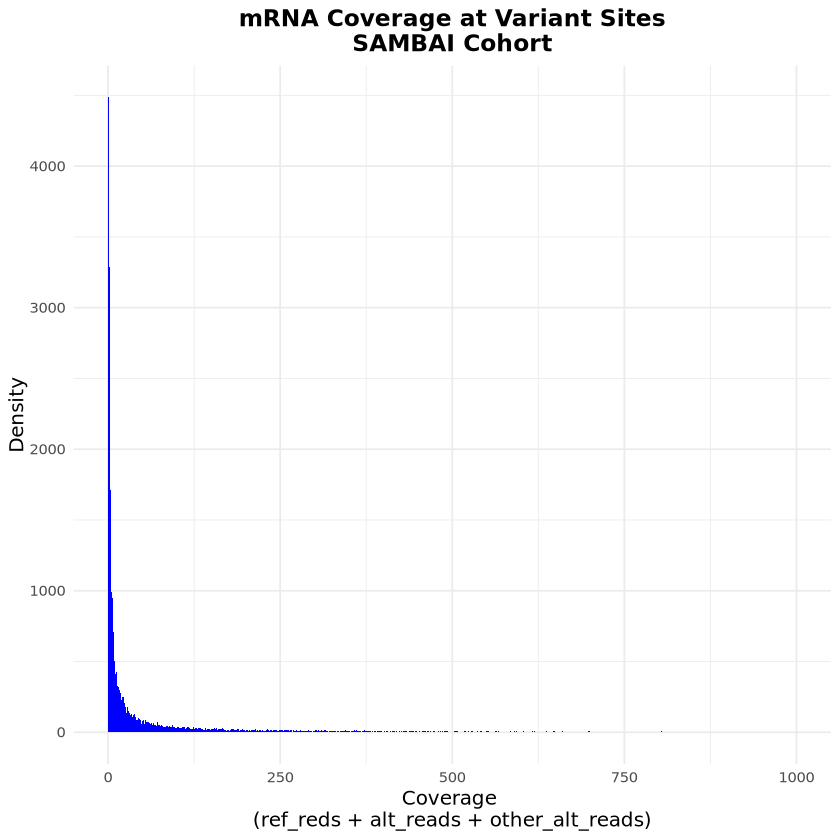

In [88]:
coverage_data %>%
    ggplot(aes(x=coverage_at_site)) + 
    geom_histogram(binwidth = 1, fill="blue") +
    xlim(c(0,1000)) +
    theme_minimal() +
    scale_fill_brewer(palette = "Set3") + 
    labs(
    title = "mRNA Coverage at Variant Sites\nSAMBAI Cohort",
    x = "Coverage \n(ref_reds + alt_reads + other_alt_reads)",
    y = "Density",
    fill = "Metric"
    ) +
    theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title.x = element_text(size = 12),
    axis.title.y = element_text(size = 12),
    legend.position = "None"
    )
    

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”


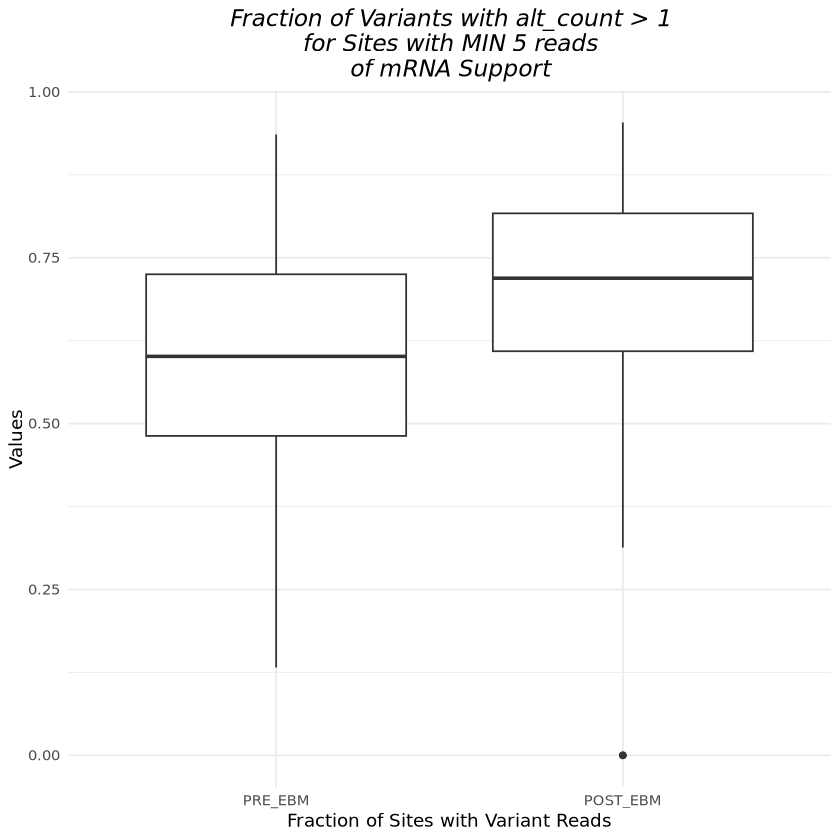

In [72]:
all_samples %>%
    mutate(
        PRE_EBM = (TP + FN) / Total, 
        POST_EBM = TP / (TP + FP)
    ) %>% 
    pivot_longer(
        cols=c(PRE_EBM, POST_EBM),
        names_to="Fractions",
        values_to="Vals"
    ) %>%
    mutate(Fractions = factor(Fractions, levels = c("PRE_EBM", "POST_EBM"))) %>%
    ggplot(aes(x=Fractions, y = Vals)) + 
    geom_boxplot() + 
    theme_minimal() +
    labs(
        title = "Fraction of Variants with alt_count > 1\nfor Sites with MIN 5 reads\nof mRNA Support",
        x = "Fraction of Sites with Variant Reads",
        y = "Values"
    ) + 
    theme(plot.title = element_text(hjust = 0.5, size = 14, face = "italic"))